In [409]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [410]:
df = pd.read_csv('Iris.csv')

In [411]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [412]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [413]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [434]:
feature_columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
x = df[feature_columns].values

In [419]:
# 1) Elbow method
wcss = []
k_values = list(range(1, 11))
for i in k_values:
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, random_state=0, n_init=20)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)

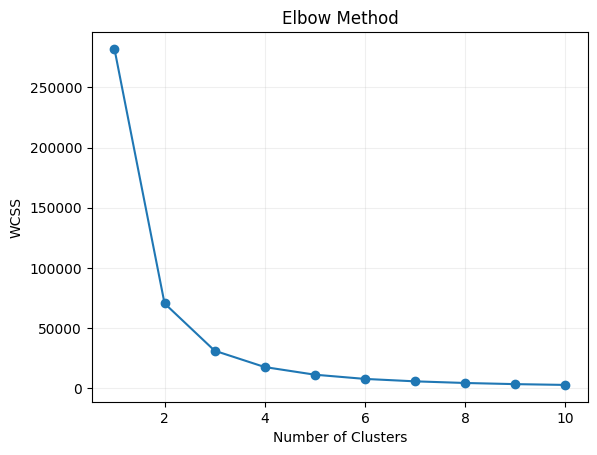

In [439]:
plt.plot(k_values, wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(alpha=0.2)
plt.show()

In [425]:
# 2) Silhouette score on k from 2 to 10 for K-Means
silhouette_scores = {}
for i in range(2, 11):
    labels = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=20).fit_predict(x)
    silhouette_scores[i] = silhouette_score(x, labels)

silhouette_k = max(silhouette_scores, key=silhouette_scores.get)
final_k = silhouette_k
print("Silhouette K Value: ", silhouette_k)

Silhouette K Value:  2


In [ ]:
# Mapping Cluster Id to actual Species Name
true_species = df['Species'].copy() if 'Species' in df.columns else None

kmeans = KMeans(n_clusters=3, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(x)
df['Cluster'] = y_kmeans

if true_species is not None:
    mapping_df = pd.DataFrame({'Cluster': y_kmeans, 'Species': true_species})
    cluster_to_species = mapping_df.groupby('Cluster')['Species'].agg(lambda s: s.value_counts().idxmax()).to_dict()
else:
    center_order = np.argsort(kmeans.cluster_centers_[:, 2])
    ordered_names = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
    cluster_to_species = {int(c): ordered_names[i] for i, c in enumerate(center_order)}

df['Species'] = pd.Series(y_kmeans).map(cluster_to_species)
print('Cluster name mapping:', cluster_to_species)

Cluster name mapping: {0: 'Iris-setosa', 1: 'Iris-versicolour', 2: 'Iris-virginica'}


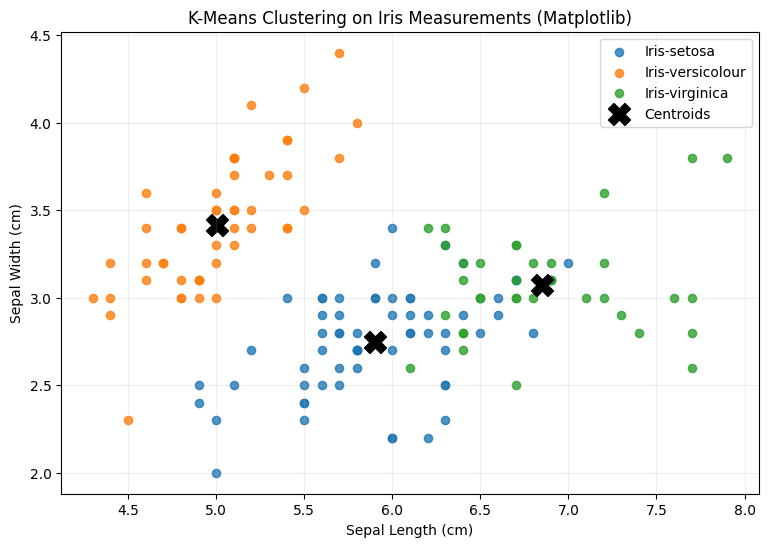

In [438]:
feature_x_name = 'Sepal Length (cm)'
feature_y_name = 'Sepal Width (cm)'

plt.figure(figsize=(9, 6))
for cluster_id in range(kmeans.n_clusters):
    mask = y_kmeans == cluster_id
    cluster_label = cluster_to_species.get(cluster_id, f'Cluster {cluster_id}')
    plt.scatter(
        x[mask, 0],
        x[mask, 1],
        s=35,
        alpha=0.8,
        label=cluster_label
    )

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=250,
    c='black',
    marker='X',
    label='Centroids'
 )

plt.title('K-Means Clustering on Iris Measurements (Matplotlib)')
plt.xlabel(feature_x_name)
plt.ylabel(feature_y_name)
plt.legend()
plt.grid(alpha=0.2)
plt.show()